# BERT 기반 텍스트 심층 분석 (Human vs AI)

이 노트북에서는 `klue/bert-base` 모델을 활용하여 텍스트의 임베딩을 추출하고,
t-SNE(2D)와 UMAP(3D)을 통해 Human 작성 텍스트와 AI 생성 텍스트의 분포 차이를 시각적으로 탐색합니다.

**주요 변경 사항:**
- **데이터 균형:** Human과 AI 데이터를 1:1 비율(각 1,000개)로 샘플링하여 클래스 불균형 문제를 해소했습니다.
- **3D 시각화:** UMAP을 활용하여 데이터의 입체적인 구조를 파악합니다.

In [ ]:
# 필요 라이브러리 설치 (최초 실행 시)
# !pip install umap-learn transformers

In [9]:
# 필요 라이브러리 임포트
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from mpl_toolkits.mplot3d import Axes3D
import platform
import seaborn as sns
import torch
from transformers import AutoTokenizer, AutoModel
from sklearn.manifold import TSNE
import umap
import os

# 한글 폰트 설정 (Robust)
def set_korean_font():
    candidates = []
    system = platform.system()
    
    if system == 'Darwin':
        candidates = ['AppleGothic', 'NanumGothic', 'NanumBarunGothic']
    elif system == 'Windows':
        candidates = ['Malgun Gothic', 'Dotum', 'Gulim']
    else:
        candidates = ['NanumGothic', 'NanumBarunGothic', 'NanumMyeongjo']

    available_fonts = set([f.name for f in fm.fontManager.ttflist])
    selected_font = None
    
    for font in candidates:
        if font in available_fonts:
            selected_font = font
            break
    
    if not selected_font:
        for f in available_fonts:
            if 'Nanum' in f or 'Gothic' in f or 'Korea' in f:
                selected_font = f
                break

    if selected_font:
        plt.rcParams['font.family'] = selected_font
        plt.rcParams['axes.unicode_minus'] = False
        print(f"✅ 한글 폰트 설정 완료: {selected_font}")
    else:
        print("⚠️ 한글 폰트를 찾을 수 없습니다. 기본 폰트를 사용합니다.")

set_korean_font()

# GPU 사용 가능 여부 확인
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Using device: {device}")

✅ 한글 폰트 설정 완료: AppleGothic
Using device: mps


## 1. 데이터 로드 및 균형 샘플링 (50:50)

In [10]:
# 데이터 로드
data_path = '/Users/youngjinson/Downloads/open/train.csv'
df = pd.read_csv(data_path)

print(f"전체 데이터 수: {len(df):,}")

# 균형 샘플링 (Human 1,000개, AI 1,000개)
df_human = df[df['generated'] == 0]
df_ai = df[df['generated'] == 1]

n_sample = 1000

# AI 데이터가 샘플 수보다 적을 경우를 대비
n_ai = min(n_sample, len(df_ai))
sample_ai = df_ai.sample(n=n_ai, random_state=42)

# Human 데이터도 동일한 수로 샘플링
sample_human = df_human.sample(n=n_ai, random_state=42)

# 데이터 병합 및 셔플
sample_df = pd.concat([sample_human, sample_ai]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\n📊 샘플링 결과:")
print(f"총 샘플 수: {len(sample_df):,}개")
print(f"Human: {len(sample_human):,}개")
print(f"AI: {len(sample_ai):,}개")
print(sample_df['generated'].value_counts(normalize=True))

전체 데이터 수: 97,172

📊 샘플링 결과:
총 샘플 수: 2,000개
Human: 1,000개
AI: 1,000개
generated
1    0.5
0    0.5
Name: proportion, dtype: float64


## 2. BERT 모델 로드 (`klue/bert-base`)

In [11]:
model_name = 'klue/bert-base'
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name).to(device)
model.eval()  # 평가 모드로 설정

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: klue/bert-base
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(32000, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
  

## 3. 임베딩 추출 함수

In [12]:
def get_bert_embeddings(text_list, batch_size=32):
    embeddings = []
    for i in range(0, len(text_list), batch_size):
        batch_texts = text_list[i:i+batch_size]
        
        # 토크나이징 (최대 길이 128로 제한하여 속도 향상)
        inputs = tokenizer(batch_texts, padding=True, truncation=True, max_length=128, return_tensors='pt').to(device)
        
        with torch.no_grad():
            outputs = model(**inputs)
            
        # [CLS] 토큰 임베딩 추출
        cls_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        embeddings.append(cls_embeddings)
        
    return np.vstack(embeddings)

# 임베딩 추출 실행
print("임베딩 추출 시작... (GPU 사용 여부 확인 필요)")
text_embeddings = get_bert_embeddings(sample_df['full_text'].tolist())
print(f"임베딩 shape: {text_embeddings.shape}")

임베딩 추출 시작... (GPU 사용 여부 확인 필요)
임베딩 shape: (2000, 768)


## 4. 차원 축소 및 시각화 (t-SNE & UMAP)

t-SNE(2D) 변환 중...


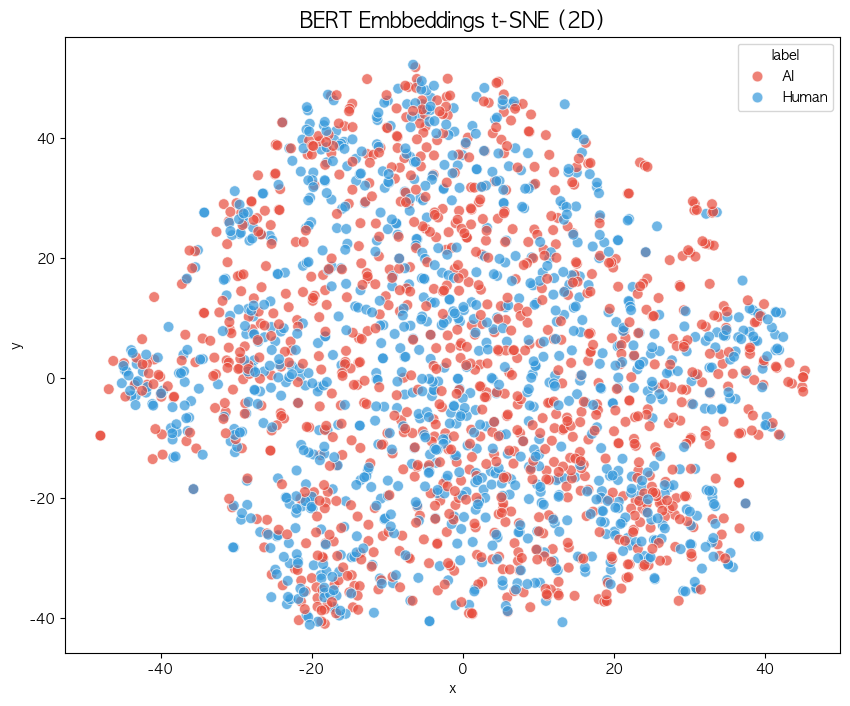

UMAP(3D) 변환 중... (umap-learn 라이브러리 필요)


/Users/youngjinson/anaconda3/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/youngjinson/anaconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


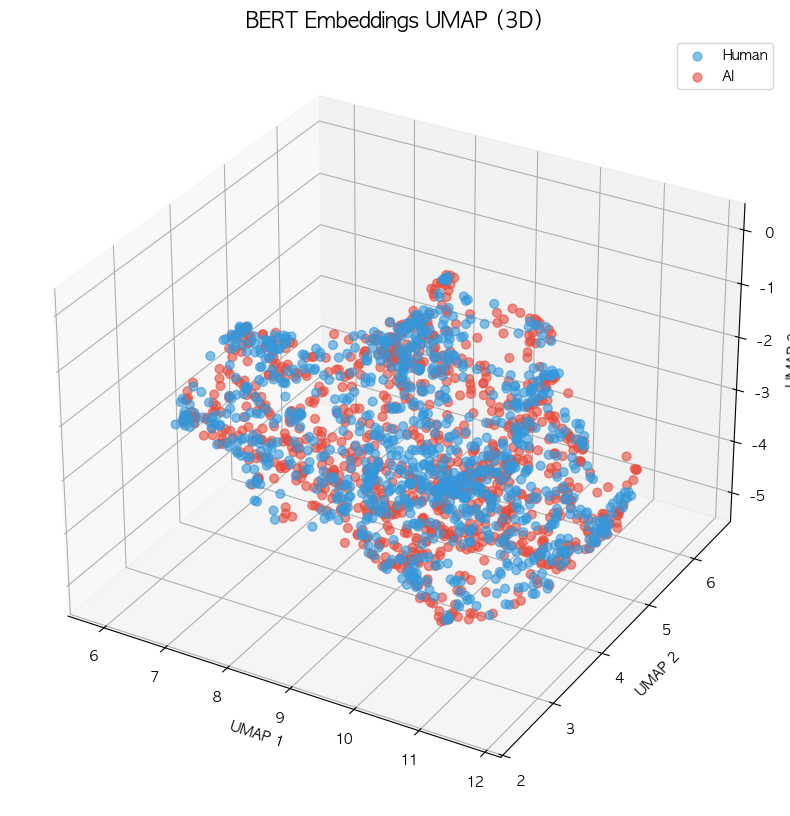

In [13]:
# 시각화 준비
targets = sample_df['generated'].map({0: 'Human', 1: 'AI'})
colors = {'Human': '#3498db', 'AI': '#e74c3c'}

# ---------------------------
# 1. t-SNE (2D Visualization)
# ---------------------------
print("t-SNE(2D) 변환 중...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
tsne_results = tsne.fit_transform(text_embeddings)

tsne_df = pd.DataFrame(data=tsne_results, columns=['x', 'y'])
tsne_df['label'] = targets

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='x', y='y', hue='label', 
    palette=colors, 
    data=tsne_df, alpha=0.7, s=60
)
plt.title('BERT Embbeddings t-SNE (2D)', fontsize=15, fontweight='bold')
plt.show()

# ---------------------------
# 2. UMAP (3D Visualization)
# ---------------------------
print("UMAP(3D) 변환 중... (umap-learn 라이브러리 필요)")
try:
    umap_3d = umap.UMAP(n_components=3, random_state=42)
    umap_results = umap_3d.fit_transform(text_embeddings)

    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')

    # Human / AI 각각 scatter
    for label, color in colors.items():
        indices = tsne_df['label'] == label
        ax.scatter(
            umap_results[indices, 0],
            umap_results[indices, 1],
            umap_results[indices, 2],
            c=color,
            label=label,
            alpha=0.6,
            s=40
        )

    ax.set_title('BERT Embeddings UMAP (3D)', fontsize=15, fontweight='bold')
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')
    ax.set_zlabel('UMAP 3')
    ax.legend()
    plt.show()
    
except ImportError:
    print("⚠️ umap-learn 라이브러리가 설치되어 있지 않아 3D 시각화를 건너뜁니다.")
    print("!pip install umap-learn 명령어로 설치해주세요.")